In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [2]:
df_ventas = pd.read_csv('../data_preprocess/df_resultado.csv')

In [3]:
df_ventas.head()

,producto,udsVenta,fecha,year,month,day,month_name,weekday_name,udsVenta_reconstruida,dia_semana,bolOpen,bolHoliday,promociones
0,1,2,2024-03-23,2024,3,23,March,Saturday,2,5,1,0,0
1,1,0,2024-03-24,2024,3,24,March,Sunday,0,6,0,1,0
2,1,7,2024-03-25,2024,3,25,March,Monday,7,0,1,0,0
3,1,7,2024-03-26,2024,3,26,March,Tuesday,7,1,1,0,0
4,1,7,2024-03-27,2024,3,27,March,Wednesday,7,2,1,0,0


## Seleccion de caracteristicas para el clustering

In [4]:
df_ventas.columns

Index(['producto', 'udsVenta', 'fecha', 'year', 'month', 'day', 'month_name',
       'weekday_name', 'udsVenta_reconstruida', 'dia_semana', 'bolOpen',
       'bolHoliday', 'promociones'],
      dtype='object')

In [5]:
df = df_ventas.copy()

features = df.groupby('producto')['udsVenta_reconstruida'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('median', 'median')
]).reset_index()

# % días con venta
pct_venta = df.groupby('producto')['udsVenta_reconstruida'] \
              .apply(lambda x: (x > 0).mean()) \
              .reset_index(name='pct_venta')

features = features.merge(pct_venta, on='producto')

In [6]:
features.head()

,producto,mean,std,min,max,median,pct_venta
0,1,6.395890,5.631650,0,37,5.0,0.776712
1,2,5.680822,4.925596,0,27,5.0,0.769863
2,3,3.328767,3.318712,0,20,2.0,0.686301
3,4,2.160274,2.691308,0,20,2.0,0.543836
4,5,3.005479,3.253779,0,20,2.0,0.634247


## Metodo del codo

In [7]:
X = features.drop(columns=['producto'])
X_scaled = StandardScaler().fit_transform(X)

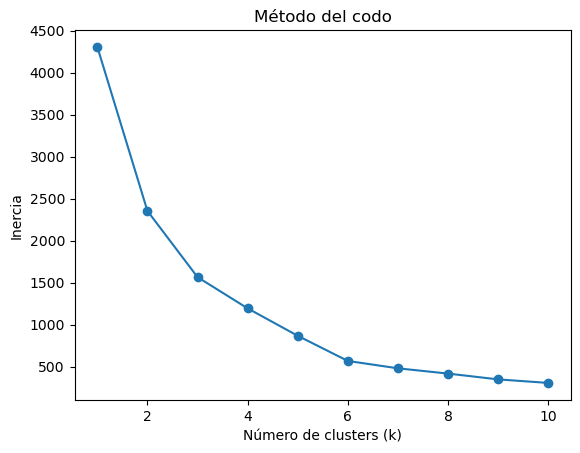

In [8]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')

plt.savefig("imgs/kmeans_codo.png", dpi=300)

plt.show()

## Aplicacion Kmeans

Aplicando el metodo del codo, usamos k = 4

In [9]:
k_optimo = 4

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(X_scaled)

In [10]:
features.groupby('cluster').mean()

,producto,mean,std,min,max,median,pct_venta
cluster,,,,,,,
0,566.124066,0.904959,1.500053,0.0,9.757848,0.007474,0.308436
1,251.752809,2.597799,2.714467,0.0,16.370787,2.348315,0.609181
2,669.000000,2.169863,19.732537,0.0,397.000000,0.000000,0.019178
3,546.461538,1.786196,6.601432,0.0,85.384615,0.153846,0.104847


In [11]:
features['cluster'].value_counts()

cluster
0    669
1    178
3     13
2      1
Name: count, dtype: int64

Reconstruccion del cluster

## Correccion Kmeans

In [12]:
# quitar outlier
features_clean = features[features['cluster'] != 2].copy()

# reconstruir X
X = features_clean.drop(columns=['producto', 'cluster'])
X_scaled = StandardScaler().fit_transform(X)

# reentrenar
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_clean['cluster'] = kmeans.fit_predict(X_scaled)

In [13]:
features_clean.groupby('cluster').mean()

,producto,mean,std,min,max,median,pct_venta
cluster,,,,,,,
0,566.124066,0.904959,1.500053,0.0,9.757848,0.007474,0.308436
1,251.752809,2.597799,2.714467,0.0,16.370787,2.348315,0.609181
2,546.461538,1.786196,6.601432,0.0,85.384615,0.153846,0.104847


In [14]:
features_clean['cluster'].value_counts()

cluster
0    669
1    178
2     13
Name: count, dtype: int64

Combinar con el dataset original

In [15]:
# merge con dataset original
df_final = df.merge(
    features_clean[['producto', 'cluster']],
    on='producto',
    how='left'
)

In [16]:
df_final.head()

,producto,udsVenta,fecha,year,month,day,month_name,weekday_name,udsVenta_reconstruida,dia_semana,bolOpen,bolHoliday,promociones,cluster
0,1,2,2024-03-23,2024,3,23,March,Saturday,2,5,1,0,0,1.0
1,1,0,2024-03-24,2024,3,24,March,Sunday,0,6,0,1,0,1.0
2,1,7,2024-03-25,2024,3,25,March,Monday,7,0,1,0,0,1.0
3,1,7,2024-03-26,2024,3,26,March,Tuesday,7,1,1,0,0,1.0
4,1,7,2024-03-27,2024,3,27,March,Wednesday,7,2,1,0,0,1.0


In [17]:
df_final['cluster'].unique()

array([ 1.,  0.,  2., nan])

## PCA

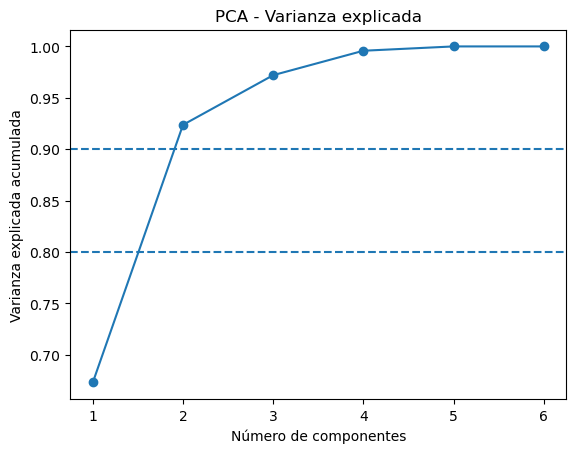

In [18]:
pca = PCA()
pca.fit(X_scaled)

# Varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure()
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')

plt.axhline(y=0.8, linestyle='--')  # línea referencia 80%
plt.axhline(y=0.9, linestyle='--')  # línea referencia 90%

plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada')
plt.savefig("imgs/pca_varianza_explicada_acumulada.png", dpi=300)

plt.show()

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

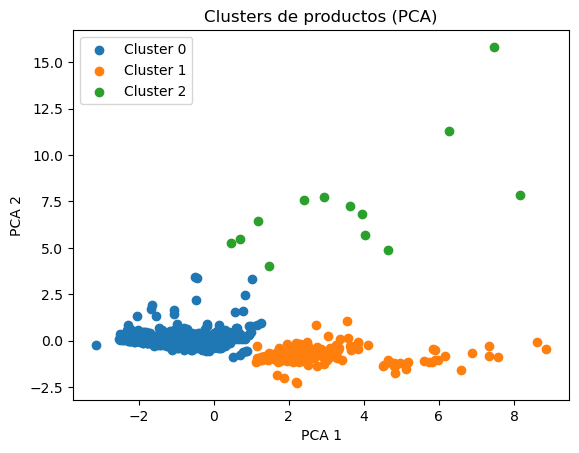

In [20]:
plt.figure()

for i in range(3):
    plt.scatter(
        X_pca[features_clean['cluster'] == i, 0],
        X_pca[features_clean['cluster'] == i, 1],
        label=f'Cluster {i}'
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters de productos (PCA)')
plt.legend()
plt.savefig("imgs/visualizacion_muestras_cluster_pca_2.png", dpi=300)

plt.show()

In [21]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.67311261 0.25059131]
0.9237039206135241


In [22]:
# df_ventas['dia_semana_sin'] = np.sin(2 * np.pi * df_ventas['dia_semana'] / 7)
# df_ventas['dia_semana_cos'] = np.cos(2 * np.pi * df_ventas['dia_semana'] / 7)

In [23]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628530 entries, 0 to 628529
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   producto               628530 non-null  int64  
 1   udsVenta               628530 non-null  int64  
 2   fecha                  628530 non-null  object 
 3   year                   628530 non-null  int64  
 4   month                  628530 non-null  int64  
 5   day                    628530 non-null  int64  
 6   month_name             628530 non-null  object 
 7   weekday_name           628530 non-null  object 
 8   udsVenta_reconstruida  628530 non-null  int64  
 9   dia_semana             628530 non-null  int64  
 10  bolOpen                628530 non-null  int64  
 11  bolHoliday             628530 non-null  int64  
 12  promociones            628530 non-null  int64  
 13  cluster                627800 non-null  float64
dtypes: float64(1), int64(10), object(3)


In [24]:
df_final = df_final.dropna().reset_index(drop=True)

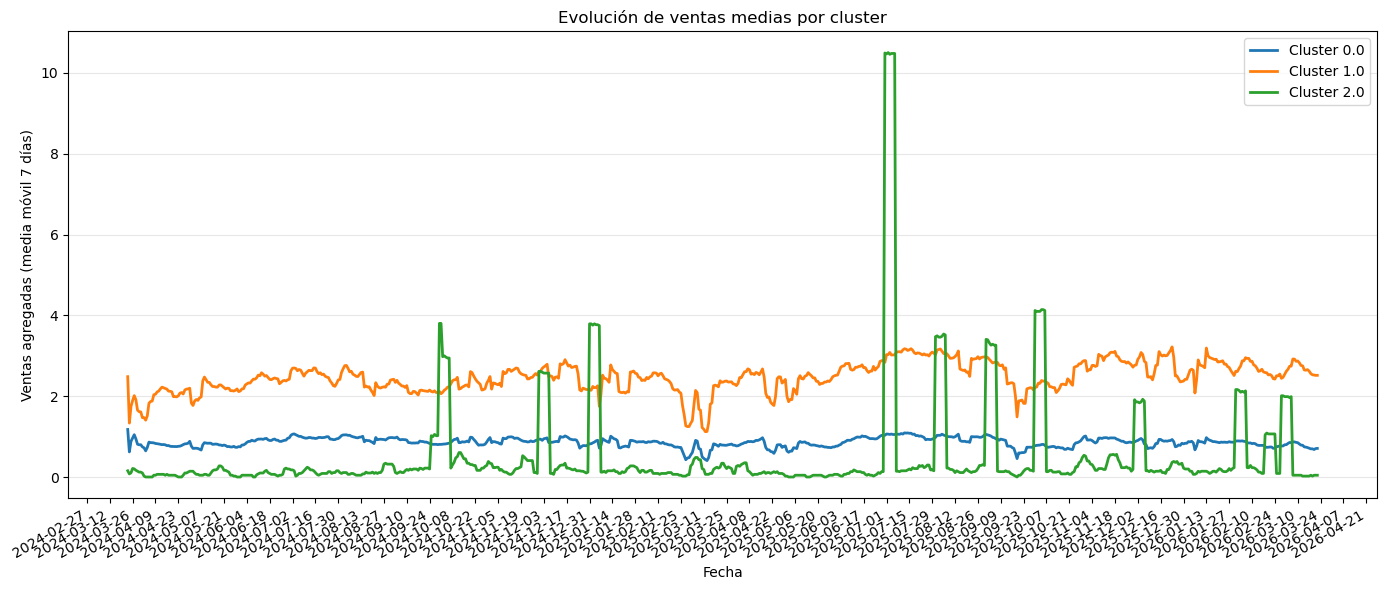

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# asegurar tipo fecha
df_final['fecha'] = pd.to_datetime(df_final['fecha'])

# ventas agregadas por fecha y cluster
ventas_diarias = (
    df_final.groupby(['fecha', 'cluster'])['udsVenta']
    .mean()
    .reset_index()
)

# media móvil 7 días por cluster
ventas_diarias['ventas_roll_7'] = (
    ventas_diarias.groupby('cluster')['udsVenta']
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

# un solo gráfico con los 3 clusters
plt.figure(figsize=(14, 6))

for cluster in sorted(ventas_diarias['cluster'].unique()):
    datos_cluster = ventas_diarias[ventas_diarias['cluster'] == cluster]
    plt.plot(
        datos_cluster['fecha'],
        datos_cluster['ventas_roll_7'],
        label=f'Cluster {cluster}',
        linewidth=2
    )

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # cada 2 semanas

plt.xlabel('Fecha')
plt.ylabel('Ventas agregadas (media móvil 7 días)')
plt.title('Evolución de ventas medias por cluster')
plt.legend()
ax.grid(True, which='major', axis='y', alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig("imgs/ventas_medias_clustering.png")

plt.show()

In [26]:
df_final.to_csv('../data_preprocess/df_ventas_clusterizado.csv', index=False)